# Task 1: Iris Exploratory Data Analysis

## Problem Statement
Analyze the Iris dataset to understand feature distributions, species-level trends, and outliers.

## Goal
Create a clear EDA workflow with visual evidence and concise insights.

## Setup, Data Loading, and Basic Preprocessing

We import required libraries, apply a consistent plot style, and load Iris through seaborn.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

try:
    df = sns.load_dataset("iris")
    if df is None or df.empty:
        raise RuntimeError("Loaded Iris dataset is empty.")
except Exception as exc:
    raise RuntimeError(
        "Failed to load Iris dataset. Check environment/internet and try again."
    ) from exc

print(f"Dataset loaded successfully with shape: {df.shape}")

Dataset loaded successfully with shape: (150, 5)


## Data Inspection and Summary Statistics

This section checks schema quality and numerical summary statistics before plotting.

In [2]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Column names: {df.columns.tolist()}")

print("\nFirst 5 rows:")
display(df.head())

print("Technical summary (.info):")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

Rows: 150, Columns: 5
Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Technical summary (.info):
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Descriptive statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Data Visualization and Exploration

We examine pairwise relationships, univariate distributions, and outlier behavior by species.

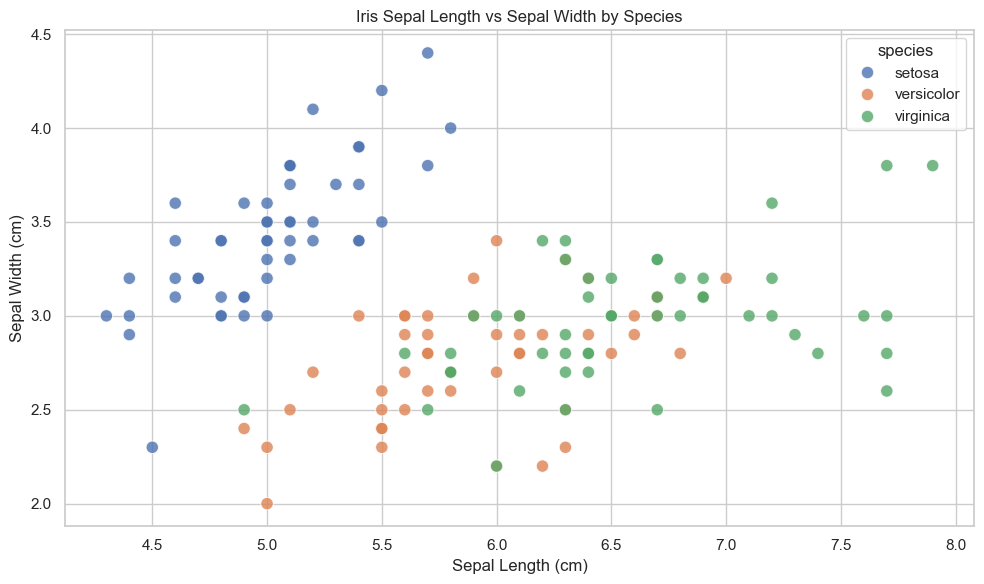

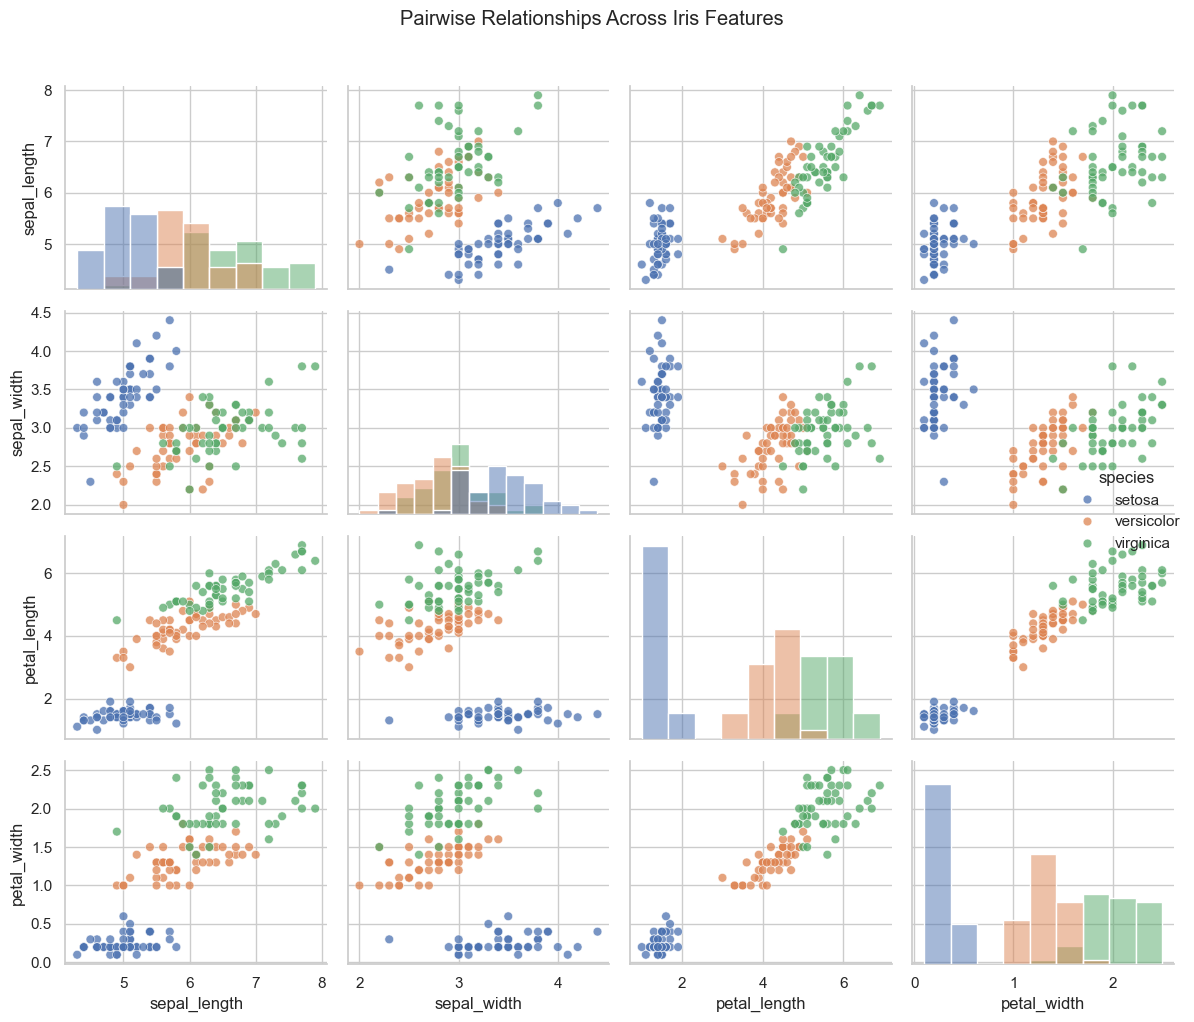

In [3]:
# Scatter plot by species
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="sepal_length", y="sepal_width", hue="species", s=80, alpha=0.8)
plt.title("Iris Sepal Length vs Sepal Width by Species")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.tight_layout()
plt.show()

# Pairplot for all features
pair_plot = sns.pairplot(df, hue="species", diag_kind="hist", plot_kws={"alpha": 0.75, "s": 40})
pair_plot.fig.set_size_inches(12, 10)
pair_plot.fig.suptitle("Pairwise Relationships Across Iris Features", y=1.02)
plt.tight_layout()
plt.show()

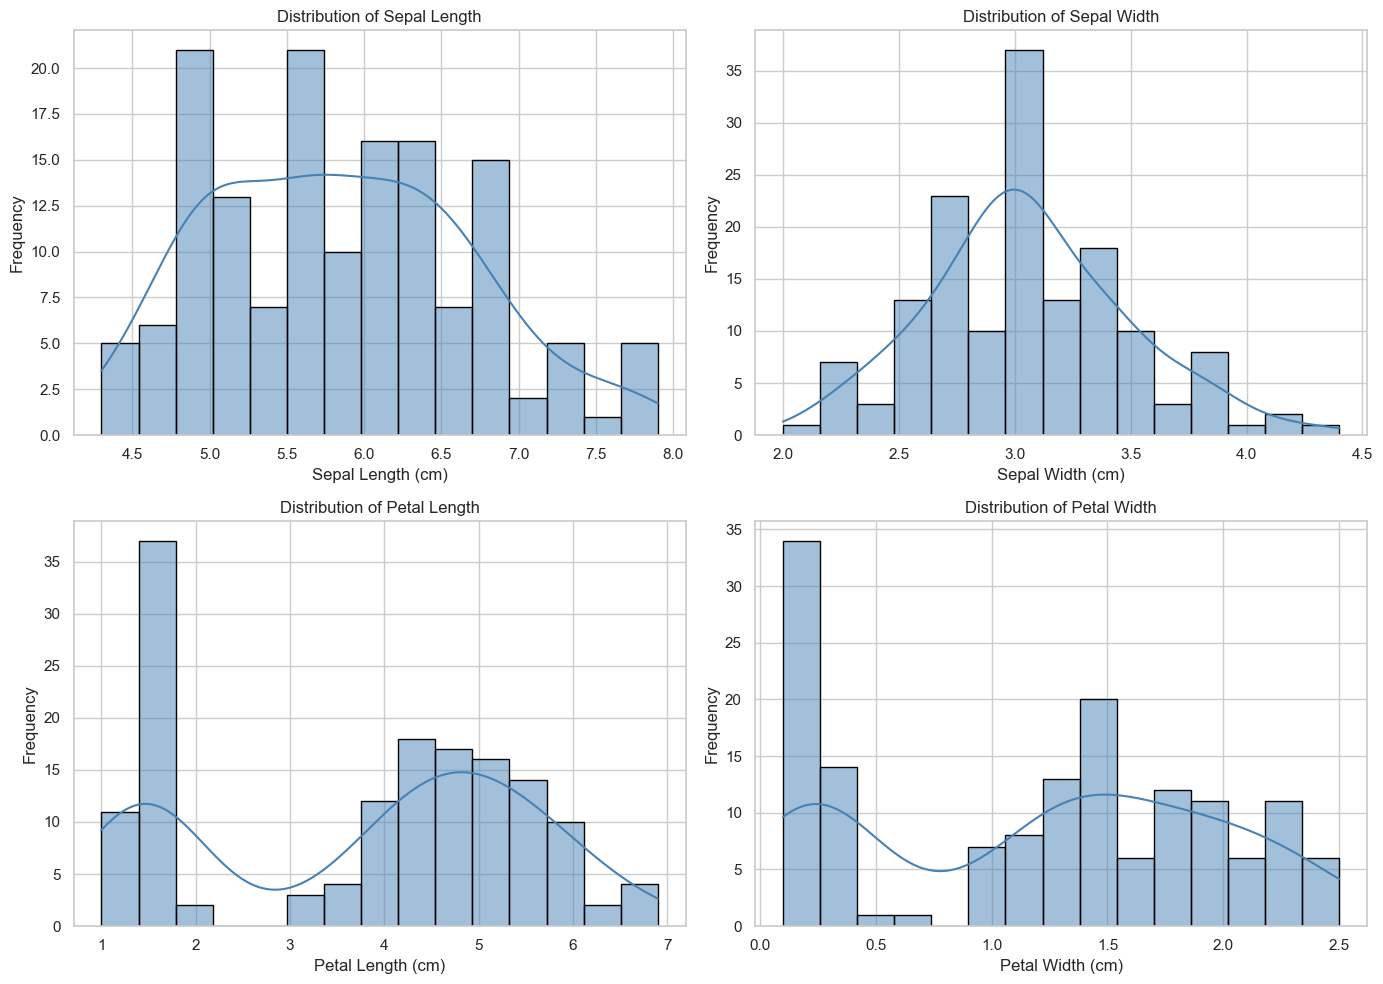

C:\Users\HP\AppData\Local\Temp\ipykernel_13308\1289053763.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, ax=axes[idx], palette="Set2")
C:\Users\HP\AppData\Local\Temp\ipykernel_13308\1289053763.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, ax=axes[idx], palette="Set2")
C:\Users\HP\AppData\Local\Temp\ipykernel_13308\1289053763.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=feature, ax=axes[idx], palette="Set2")
C:\Users\HP\AppData\Local

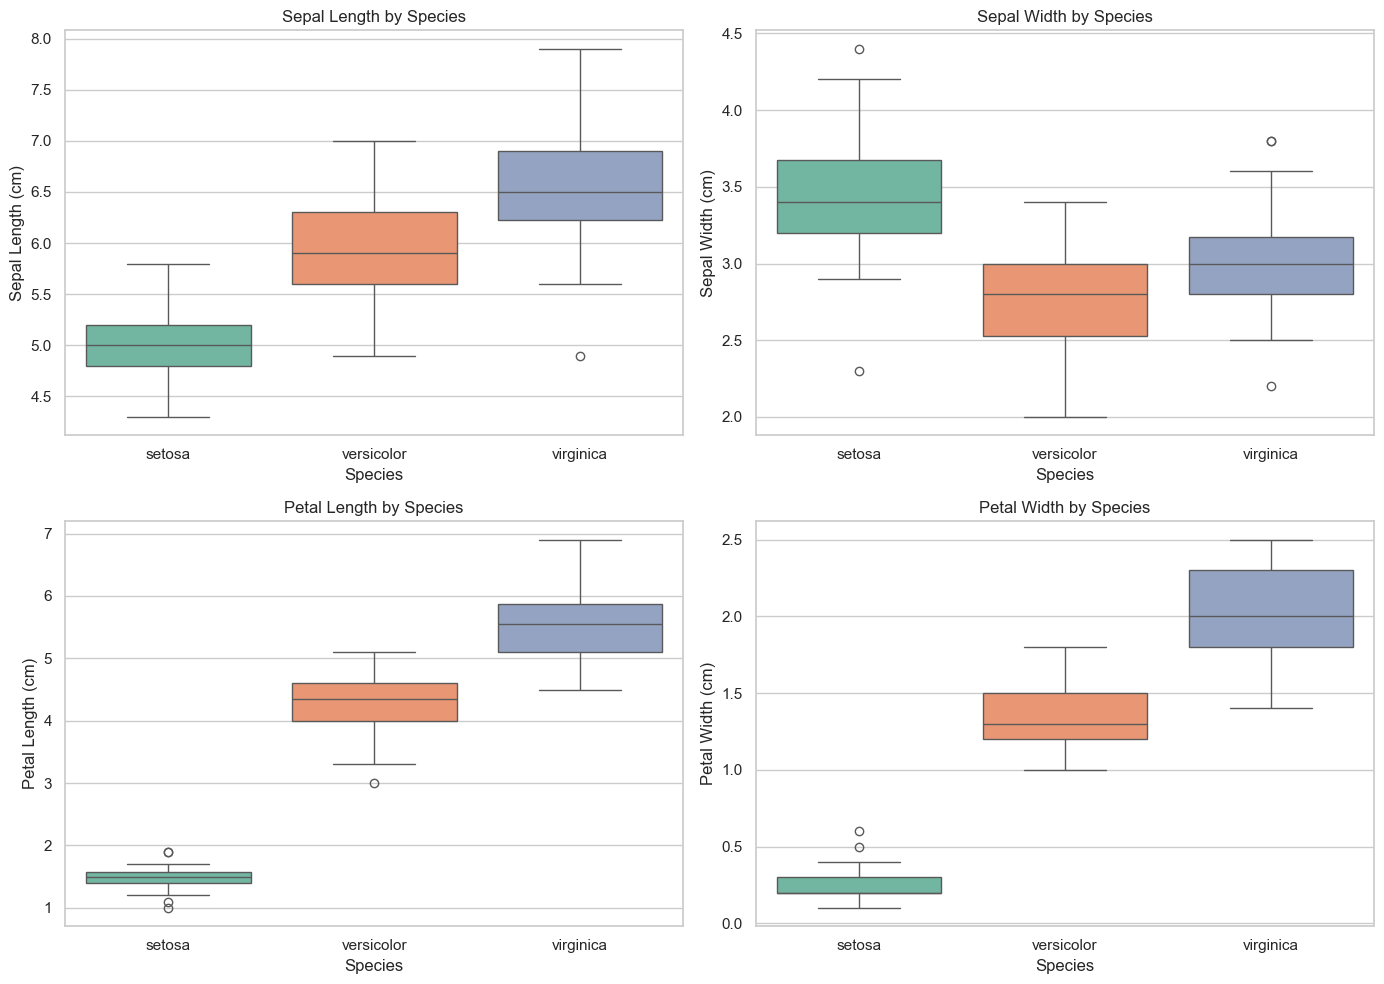

In [4]:
numeric_features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

# Histograms + KDE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, feature in enumerate(numeric_features):
    sns.histplot(data=df, x=feature, kde=True, bins=15, ax=axes[idx], color="steelblue", edgecolor="black")
    axes[idx].set_title(f"Distribution of {feature.replace('_', ' ').title()}")
    axes[idx].set_xlabel(f"{feature.replace('_', ' ').title()} (cm)")
    axes[idx].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

# Boxplots by species
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, feature in enumerate(numeric_features):
    sns.boxplot(data=df, x="species", y=feature, ax=axes[idx], palette="Set2")
    axes[idx].set_title(f"{feature.replace('_', ' ').title()} by Species")
    axes[idx].set_xlabel("Species")
    axes[idx].set_ylabel(f"{feature.replace('_', ' ').title()} (cm)")
plt.tight_layout()
plt.show()

## Results and Final Insights

- Petal-based features show stronger species separation than sepal features.
- Setosa is clearly separated in most pairwise plots; versicolor and virginica partially overlap.
- Boxplots indicate potential outliers in a few feature-species groups, but overall class patterns remain stable.
- This EDA supports using petal features as high-signal inputs for downstream classification tasks.